# Healthcare Operations Analytics — EDV Peer Benchmarking Notebook

## Purpose

This notebook performs Block 7 of the Healthcare Operations Analytics mini project.

It uses the SQL-validated analytical mart and the profiling results from Block 6 to benchmark hospitals within ED-volume peer categories.

The goal is to calculate peer-relative metrics for OP_18b and OP_22, including EDV-tier medians, percentiles, and hospital-level variance from peer benchmarks.

## Scope Guardrail

This notebook supports operational review prioritization.

It does not create a definitive hospital ranking, diagnose operational causes, or make causal claims about ED wait times and patients leaving before being seen.

## 1. Load Analytical Mart and Create Benchmark Population

This section loads the Phase 2 analytical mart and creates the complete-case benchmarking population.

Benchmarking requires hospitals to have:

- EDV category
- OP_18b median wait time
- OP_22 left-without-being-seen percentage

In [1]:
import pandas as pd
from pathlib import Path

project_root = Path.cwd().parent
processed_path = project_root / "data" / "processed"
mart_path = processed_path / "healthcare_ed_throughput_mart.csv"

df = pd.read_csv(
    mart_path,
    dtype={"facility_id": "string"}
)

benchmark_fields = [
    "ed_volume_category",
    "op_18b_median_wait_min",
    "op_22_lwbs_pct"
]

analysis_df = df.dropna(subset=benchmark_fields).copy()

print("Mart shape:", df.shape)
print("Benchmark population rows:", len(analysis_df))
print("Unique benchmark facilities:", analysis_df["facility_id"].nunique())

display(
    analysis_df[
        [
            "facility_id",
            "facility_name",
            "state",
            "ed_volume_category",
            "op_18b_median_wait_min",
            "op_22_lwbs_pct"
        ]
    ].head()
)

Mart shape: (4660, 22)
Benchmark population rows: 3777
Unique benchmark facilities: 3777


,facility_id,facility_name,state,ed_volume_category,op_18b_median_wait_min,op_22_lwbs_pct
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,very high,217.0,3.0
1,010005,MARSHALL MEDICAL CENTERS,AL,very high,141.0,3.0
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,high,144.0,1.0
3,010007,MIZELL MEMORIAL HOSPITAL,AL,low,128.0,1.0
5,010012,DEKALB REGIONAL MEDICAL CENTER,AL,medium,164.0,2.0


## 2. EDV-Tier Peer Benchmark Summary

This section calculates descriptive benchmarks within each ED-volume category.

The benchmark statistics include medians and upper percentiles for:

- OP_18b median ED arrival-to-departure time
- OP_22 left-without-being-seen percentage

These benchmarks are used for operational screening, not causal diagnosis or definitive hospital ranking.

In [2]:
peer_benchmark_summary = (
    analysis_df
    .groupby("ed_volume_category")
    .agg(
        hospital_count=("facility_id", "count"),
        op_18b_median=("op_18b_median_wait_min", "median"),
        op_18b_p75=("op_18b_median_wait_min", lambda x: x.quantile(0.75)),
        op_18b_p90=("op_18b_median_wait_min", lambda x: x.quantile(0.90)),
        op_22_median=("op_22_lwbs_pct", "median"),
        op_22_p75=("op_22_lwbs_pct", lambda x: x.quantile(0.75)),
        op_22_p90=("op_22_lwbs_pct", lambda x: x.quantile(0.90)),
    )
    .reset_index()
    .sort_values("ed_volume_category")
)

display(peer_benchmark_summary)

,ed_volume_category,hospital_count,op_18b_median,op_18b_p75,op_18b_p90,op_22_median,op_22_p75,op_22_p90
0,high,551,190.0,219.0,252.0,2.0,3.0,5.0
1,low,1612,120.0,140.0,162.9,1.0,1.0,3.0
2,medium,911,168.0,194.0,218.0,2.0,3.0,4.0
3,very high,703,194.0,231.0,271.6,2.0,3.0,5.0


## 3. Hospital-Level Peer Benchmark Fields

This section assigns EDV-tier benchmark values to each hospital in the complete-case benchmarking population.

For each hospital, the analysis calculates:

- EDV-tier median OP_18b
- EDV-tier 75th and 90th percentile OP_18b
- EDV-tier median OP_22
- EDV-tier 75th and 90th percentile OP_22
- variance from the EDV-tier median for each outcome

These fields support operational review prioritization while keeping comparisons within ED-volume peer categories.

In [6]:
analysis_df["op_18b_peer_median"] = (
    analysis_df
    .groupby("ed_volume_category")["op_18b_median_wait_min"]
    .transform("median")
)

analysis_df["op_18b_peer_p75"] = (
    analysis_df
    .groupby("ed_volume_category")["op_18b_median_wait_min"]
    .transform(lambda x: x.quantile(0.75))
)

analysis_df["op_18b_peer_p90"] = (
    analysis_df
    .groupby("ed_volume_category")["op_18b_median_wait_min"]
    .transform(lambda x: x.quantile(0.90))
)

analysis_df["op_18b_variance_from_peer_median"] = (
    analysis_df["op_18b_median_wait_min"] - analysis_df["op_18b_peer_median"]
)

analysis_df["op_22_peer_median"] = (
    analysis_df
    .groupby("ed_volume_category")["op_22_lwbs_pct"]
    .transform("median")
)

analysis_df["op_22_peer_p75"] = (
    analysis_df
    .groupby("ed_volume_category")["op_22_lwbs_pct"]
    .transform(lambda x: x.quantile(0.75))
)

analysis_df["op_22_peer_p90"] = (
    analysis_df
    .groupby("ed_volume_category")["op_22_lwbs_pct"]
    .transform(lambda x: x.quantile(0.90))
)

analysis_df["op_22_variance_from_peer_median"] = (
    analysis_df["op_22_lwbs_pct"] - analysis_df["op_22_peer_median"]
)

In [7]:
display(
    analysis_df[
        [
            "facility_id",
            "facility_name",
            "state",
            "ed_volume_category",
            "op_18b_median_wait_min",
            "op_18b_peer_median",
            "op_18b_variance_from_peer_median",
            "op_22_lwbs_pct",
            "op_22_peer_median",
            "op_22_variance_from_peer_median"
        ]
    ].head()
)

,facility_id,facility_name,state,ed_volume_category,op_18b_median_wait_min,op_18b_peer_median,op_18b_variance_from_peer_median,op_22_lwbs_pct,op_22_peer_median,op_22_variance_from_peer_median
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,very high,217.0,194.0,23.0,3.0,2.0,1.0
1,010005,MARSHALL MEDICAL CENTERS,AL,very high,141.0,194.0,-53.0,3.0,2.0,1.0
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,high,144.0,190.0,-46.0,1.0,2.0,-1.0
3,010007,MIZELL MEMORIAL HOSPITAL,AL,low,128.0,120.0,8.0,1.0,1.0,0.0
5,010012,DEKALB REGIONAL MEDICAL CENTER,AL,medium,164.0,168.0,-4.0,2.0,2.0,0.0


In [8]:
validation_summary = (
    analysis_df
    .groupby("ed_volume_category")
    .agg(
        hospital_count=("facility_id", "count"),
        assigned_op_18b_peer_median=("op_18b_peer_median", "first"),
        actual_op_18b_median=("op_18b_median_wait_min", "median"),
        assigned_op_22_peer_median=("op_22_peer_median", "first"),
        actual_op_22_median=("op_22_lwbs_pct", "median"),
    )
    .reset_index()
)

validation_summary["op_18b_median_match"] = (
    validation_summary["assigned_op_18b_peer_median"]
    == validation_summary["actual_op_18b_median"]
)

validation_summary["op_22_median_match"] = (
    validation_summary["assigned_op_22_peer_median"]
    == validation_summary["actual_op_22_median"]
)

display(validation_summary)

,ed_volume_category,hospital_count,assigned_op_18b_peer_median,actual_op_18b_median,assigned_op_22_peer_median,actual_op_22_median,op_18b_median_match,op_22_median_match
0,high,551,190.0,190.0,2.0,2.0,True,True
1,low,1612,120.0,120.0,1.0,1.0,True,True
2,medium,911,168.0,168.0,2.0,2.0,True,True
3,very high,703,194.0,194.0,2.0,2.0,True,True


## 4. Review-Priority Flag Logic

This section creates simple percentile-based review-priority flags.

A hospital is flagged if it is at or above the EDV-tier 90th percentile for:

- OP_18b median ED arrival-to-departure time, or
- OP_22 left-without-being-seen percentage

This flag identifies hospitals that may warrant operational review. It does not label hospitals as poor performers, does not diagnose causes, and does not create a definitive ranking.

In [9]:
analysis_df["op_18b_high_wait_flag"] = (
    analysis_df["op_18b_median_wait_min"] >= analysis_df["op_18b_peer_p90"]
)

analysis_df["op_22_high_lwbs_flag"] = (
    analysis_df["op_22_lwbs_pct"] >= analysis_df["op_22_peer_p90"]
)

analysis_df["review_priority_flag"] = (
    analysis_df["op_18b_high_wait_flag"] | analysis_df["op_22_high_lwbs_flag"]
)

priority_summary = (
    analysis_df
    .agg(
        total_hospitals=("facility_id", "count"),
        high_wait_count=("op_18b_high_wait_flag", "sum"),
        high_lwbs_count=("op_22_high_lwbs_flag", "sum"),
        review_priority_count=("review_priority_flag", "sum")
    )
)

display(priority_summary)

,facility_id,op_18b_high_wait_flag,op_22_high_lwbs_flag,review_priority_flag
total_hospitals,3777.0,NaN,NaN,NaN
high_wait_count,NaN,386.0,NaN,NaN
high_lwbs_count,NaN,NaN,437.0,NaN
review_priority_count,NaN,NaN,NaN,678.0


In [10]:
priority_summary = pd.DataFrame({
    "metric": [
        "total_hospitals",
        "high_wait_count",
        "high_lwbs_count",
        "review_priority_count"
    ],
    "count": [
        len(analysis_df),
        analysis_df["op_18b_high_wait_flag"].sum(),
        analysis_df["op_22_high_lwbs_flag"].sum(),
        analysis_df["review_priority_flag"].sum()
    ]
})

priority_summary["pct_of_benchmark_population"] = (
    priority_summary["count"] / len(analysis_df) * 100
)

display(priority_summary)

,metric,count,pct_of_benchmark_population
0,total_hospitals,3777,100.000000
1,high_wait_count,386,10.219751
2,high_lwbs_count,437,11.570029
3,review_priority_count,678,17.950755


In [11]:
flag_overlap_summary = pd.DataFrame({
    "metric": [
        "high_wait_only",
        "high_lwbs_only",
        "both_high_wait_and_high_lwbs",
        "any_review_priority"
    ],
    "count": [
        ((analysis_df["op_18b_high_wait_flag"]) & (~analysis_df["op_22_high_lwbs_flag"])).sum(),
        ((~analysis_df["op_18b_high_wait_flag"]) & (analysis_df["op_22_high_lwbs_flag"])).sum(),
        ((analysis_df["op_18b_high_wait_flag"]) & (analysis_df["op_22_high_lwbs_flag"])).sum(),
        analysis_df["review_priority_flag"].sum()
    ]
})

flag_overlap_summary["pct_of_benchmark_population"] = (
    flag_overlap_summary["count"] / len(analysis_df) * 100
)

display(flag_overlap_summary)

,metric,count,pct_of_benchmark_population
0,high_wait_only,241,6.380725
1,high_lwbs_only,292,7.731003
2,both_high_wait_and_high_lwbs,145,3.839026
3,any_review_priority,678,17.950755


## 5. Review-Priority Candidate Table

This section creates a review-priority table for hospitals flagged by the EDV-tier 90th percentile logic.

The table is intended to help stakeholders identify hospitals that may warrant further operational review. It should not be interpreted as a definitive ranking of hospital quality or management performance.

In [12]:
review_priority_df = (
    analysis_df[analysis_df["review_priority_flag"]]
    .copy()
)

review_priority_df["review_priority_type"] = "One indicator high"

review_priority_df.loc[
    review_priority_df["op_18b_high_wait_flag"] & review_priority_df["op_22_high_lwbs_flag"],
    "review_priority_type"
] = "Both indicators high"

review_priority_df.loc[
    review_priority_df["op_18b_high_wait_flag"] & ~review_priority_df["op_22_high_lwbs_flag"],
    "review_priority_type"
] = "High wait only"

review_priority_df.loc[
    ~review_priority_df["op_18b_high_wait_flag"] & review_priority_df["op_22_high_lwbs_flag"],
    "review_priority_type"
] = "High LWBS only"

review_priority_table = (
    review_priority_df[
        [
            "facility_id",
            "facility_name",
            "state",
            "ed_volume_category",
            "review_priority_type",
            "op_18b_median_wait_min",
            "op_18b_peer_p90",
            "op_18b_variance_from_peer_median",
            "op_22_lwbs_pct",
            "op_22_peer_p90",
            "op_22_variance_from_peer_median"
        ]
    ]
    .sort_values(
        by=[
            "review_priority_type",
            "op_18b_variance_from_peer_median",
            "op_22_variance_from_peer_median"
        ],
        ascending=[True, False, False]
    )
)

display(review_priority_table.head(20))

,facility_id,facility_name,state,ed_volume_category,review_priority_type,op_18b_median_wait_min,op_18b_peer_p90,op_18b_variance_from_peer_median,op_22_lwbs_pct,op_22_peer_p90,op_22_variance_from_peer_median
413,050327,LOMA LINDA UNIVERSITY MEDICAL CENTER,CA,very high,Both indicators high,464.0,271.6,270.0,6.0,5.0,4.0
543,050776,COLLEGE MEDICAL CENTER,CA,low,Both indicators high,330.0,162.9,210.0,9.0,3.0,8.0
728,090011,MEDSTAR WASHINGTON HOSPITAL CENTER,DC,very high,Both indicators high,400.0,271.6,206.0,5.0,5.0,3.0
723,090001,GEORGE WASHINGTON UNIV HOSPITAL,DC,high,Both indicators high,380.0,252.0,190.0,12.0,5.0,10.0
2774,330057,ST PETER'S HOSPITAL,NY,high,Both indicators high,374.0,252.0,184.0,7.0,5.0,5.0
725,090004,MEDSTAR GEORGETOWN UNIVERSITY HOSPITAL,DC,high,Both indicators high,371.0,252.0,181.0,10.0,5.0,8.0
2839,330219,ERIE COUNTY MEDICAL CENTER,NY,medium,Both indicators high,346.0,218.0,178.0,8.0,4.0,6.0
494,050625,CEDARS-SINAI MEDICAL CENTER,CA,very high,Both indicators high,369.0,271.6,175.0,9.0,5.0,7.0
1160,140119,RUSH UNIVERSITY MEDICAL CENTER,IL,very high,Both indicators high,358.0,271.6,164.0,9.0,5.0,7.0
955,110078,EMORY UNIVERSITY HOSPITAL MIDTOWN,GA,very high,Both indicators high,345.0,271.6,151.0,6.0,5.0,4.0


### Review-Priority Sorting Logic

Review-priority candidates are sorted using an explicit review-priority order:

1. Both indicators high
2. High wait only
3. High LWBS only

Within each group, hospitals are sorted by variance from EDV-tier peer median. This creates a practical operational review queue, not a definitive ranking of hospital quality.

In [13]:
priority_order = {
    "Both indicators high": 1,
    "High wait only": 2,
    "High LWBS only": 3
}

review_priority_table["priority_rank"] = (
    review_priority_table["review_priority_type"].map(priority_order)
)

review_priority_table = (
    review_priority_table
    .sort_values(
        by=[
            "priority_rank",
            "op_18b_variance_from_peer_median",
            "op_22_variance_from_peer_median"
        ],
        ascending=[True, False, False]
    )
)

display(review_priority_table.head(20))

,facility_id,facility_name,state,ed_volume_category,review_priority_type,op_18b_median_wait_min,op_18b_peer_p90,op_18b_variance_from_peer_median,op_22_lwbs_pct,op_22_peer_p90,op_22_variance_from_peer_median,priority_rank
413,050327,LOMA LINDA UNIVERSITY MEDICAL CENTER,CA,very high,Both indicators high,464.0,271.6,270.0,6.0,5.0,4.0,1
543,050776,COLLEGE MEDICAL CENTER,CA,low,Both indicators high,330.0,162.9,210.0,9.0,3.0,8.0,1
728,090011,MEDSTAR WASHINGTON HOSPITAL CENTER,DC,very high,Both indicators high,400.0,271.6,206.0,5.0,5.0,3.0,1
723,090001,GEORGE WASHINGTON UNIV HOSPITAL,DC,high,Both indicators high,380.0,252.0,190.0,12.0,5.0,10.0,1
2774,330057,ST PETER'S HOSPITAL,NY,high,Both indicators high,374.0,252.0,184.0,7.0,5.0,5.0,1
725,090004,MEDSTAR GEORGETOWN UNIVERSITY HOSPITAL,DC,high,Both indicators high,371.0,252.0,181.0,10.0,5.0,8.0,1
2839,330219,ERIE COUNTY MEDICAL CENTER,NY,medium,Both indicators high,346.0,218.0,178.0,8.0,4.0,6.0,1
494,050625,CEDARS-SINAI MEDICAL CENTER,CA,very high,Both indicators high,369.0,271.6,175.0,9.0,5.0,7.0,1
1160,140119,RUSH UNIVERSITY MEDICAL CENTER,IL,very high,Both indicators high,358.0,271.6,164.0,9.0,5.0,7.0,1
955,110078,EMORY UNIVERSITY HOSPITAL MIDTOWN,GA,very high,Both indicators high,345.0,271.6,151.0,6.0,5.0,4.0,1


In [14]:
processed_path = project_root / "data" / "processed"

peer_benchmark_summary_path = processed_path / "healthcare_ed_peer_benchmark_summary.csv"
benchmark_analysis_path = processed_path / "healthcare_ed_benchmark_analysis_table.csv"
review_priority_path = processed_path / "healthcare_ed_review_priority_table.csv"

peer_benchmark_summary.to_csv(peer_benchmark_summary_path, index=False)
analysis_df.to_csv(benchmark_analysis_path, index=False)
review_priority_table.to_csv(review_priority_path, index=False)

print("Export complete.")
print("Peer benchmark summary:", peer_benchmark_summary_path)
print("Benchmark analysis table:", benchmark_analysis_path)
print("Review priority table:", review_priority_path)

print("\nRows exported:")
print("peer_benchmark_summary:", len(peer_benchmark_summary))
print("analysis_df:", len(analysis_df))
print("review_priority_table:", len(review_priority_table))

Export complete.
Peer benchmark summary: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\data\processed\healthcare_ed_peer_benchmark_summary.csv
Benchmark analysis table: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\data\processed\healthcare_ed_benchmark_analysis_table.csv
Review priority table: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\data\processed\healthcare_ed_review_priority_table.csv

Rows exported:
peer_benchmark_summary: 4
analysis_df: 3777
review_priority_table: 678


## Block 8 — Visuals

This section creates stakeholder-relevant visuals for the Healthcare Operations Analytics mini project.

The visuals focus on ED throughput screening using:

- OP_18b median ED arrival-to-departure time
- OP_22 left-without-being-seen percentage
- EDV peer categories
- review-priority flags

The visuals are descriptive and should not be interpreted as causal evidence or definitive hospital rankings.

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

figures_path = project_root / "outputs" / "figures"
figures_path.mkdir(parents=True, exist_ok=True)

print("Figures path:", figures_path)

Figures path: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\outputs\figures


### Visual 1 — OP_18b Distribution by EDV Tier

This visual compares median ED arrival-to-departure time across ED-volume peer categories.

It helps stakeholders see whether higher-volume ED categories tend to have longer wait-time distributions and wider upper tails.

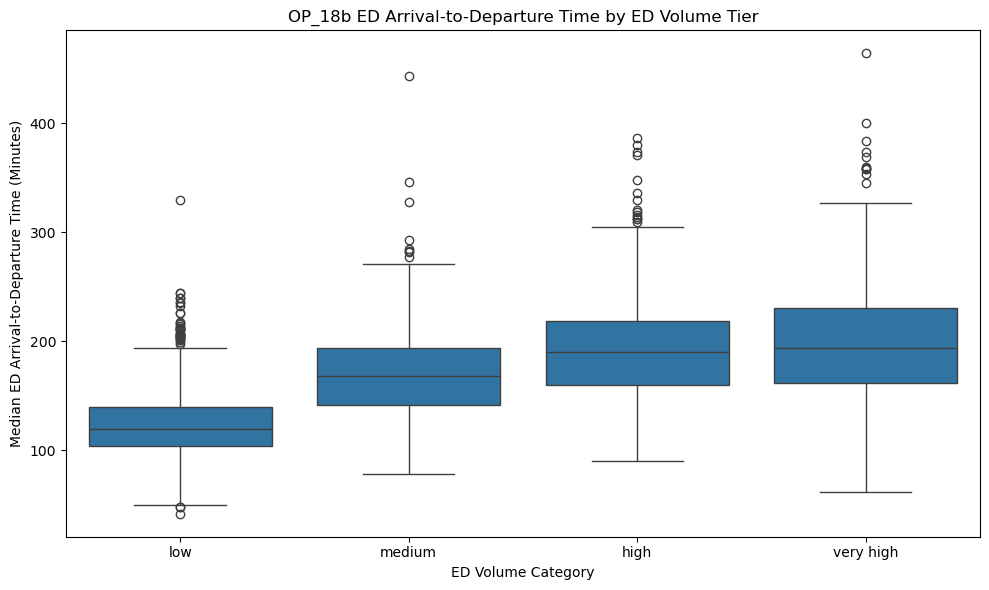

Saved: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\outputs\figures\op18b_wait_time_by_ed_volume.png


In [16]:
edv_order = ["low", "medium", "high", "very high"]

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=analysis_df,
    x="ed_volume_category",
    y="op_18b_median_wait_min",
    order=edv_order
)

plt.title("OP_18b ED Arrival-to-Departure Time by ED Volume Tier")
plt.xlabel("ED Volume Category")
plt.ylabel("Median ED Arrival-to-Departure Time (Minutes)")

plt.tight_layout()

visual1_path = figures_path / "op18b_wait_time_by_ed_volume.png"
plt.savefig(visual1_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", visual1_path)

### Visual 2 — OP_22 Left Without Being Seen by EDV Tier

This visual compares left-without-being-seen percentages across ED-volume peer categories.

It helps stakeholders assess whether higher ED-volume categories show higher LWBS distributions or upper-tail values.

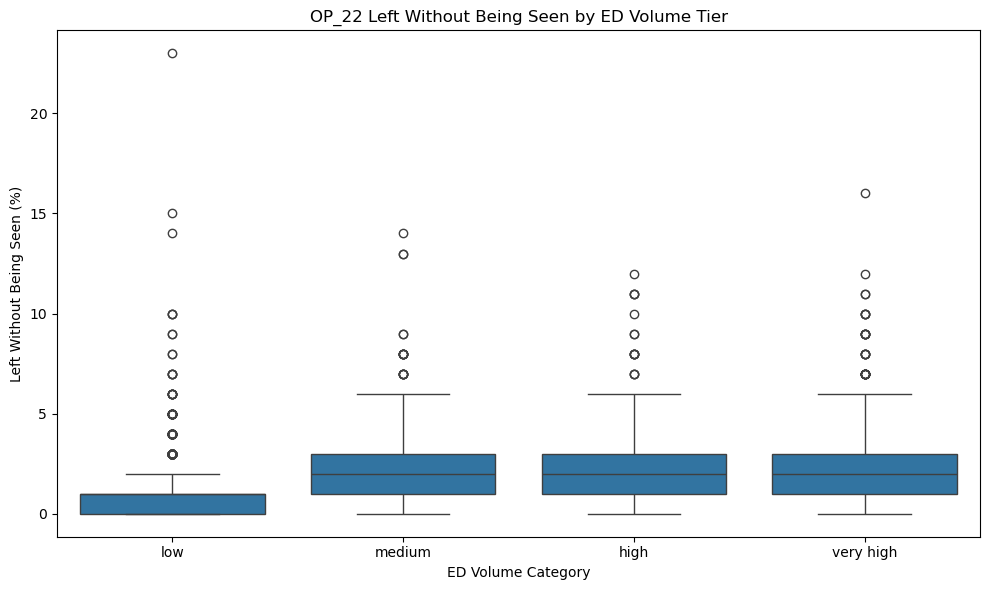

Saved: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\outputs\figures\op22_lwbs_by_ed_volume.png


In [17]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=analysis_df,
    x="ed_volume_category",
    y="op_22_lwbs_pct",
    order=edv_order
)

plt.title("OP_22 Left Without Being Seen by ED Volume Tier")
plt.xlabel("ED Volume Category")
plt.ylabel("Left Without Being Seen (%)")

plt.tight_layout()

visual2_path = figures_path / "op22_lwbs_by_ed_volume.png"
plt.savefig(visual2_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", visual2_path)

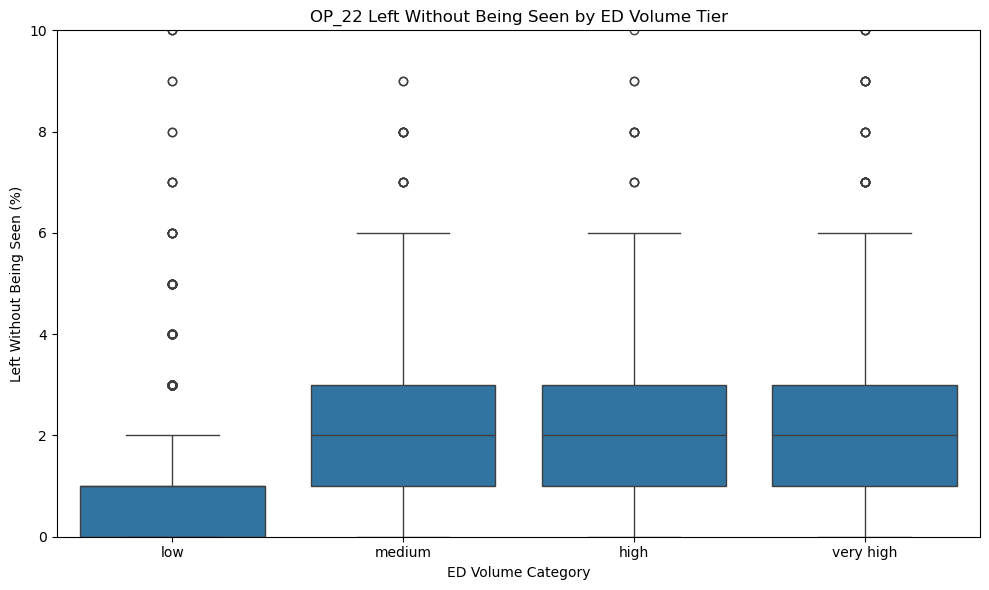

Saved: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\outputs\figures\op22_lwbs_by_ed_volume_zoomed.png


In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=analysis_df,
    x="ed_volume_category",
    y="op_22_lwbs_pct",
    order=edv_order
)

plt.ylim(0, 10)

plt.title("OP_22 Left Without Being Seen by ED Volume Tier")
plt.xlabel("ED Volume Category")
plt.ylabel("Left Without Being Seen (%)")

plt.tight_layout()

visual2_zoom_path = figures_path / "op22_lwbs_by_ed_volume_zoomed.png"
plt.savefig(visual2_zoom_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", visual2_zoom_path)

### Visual 3 — OP_18b vs OP_22 with Review-Priority Flag

This visual compares median ED arrival-to-departure time against left-without-being-seen percentage.

Hospitals are colored by review-priority flag to show whether flagged hospitals cluster in higher-throughput-risk areas. This visual supports screening, not causal interpretation.

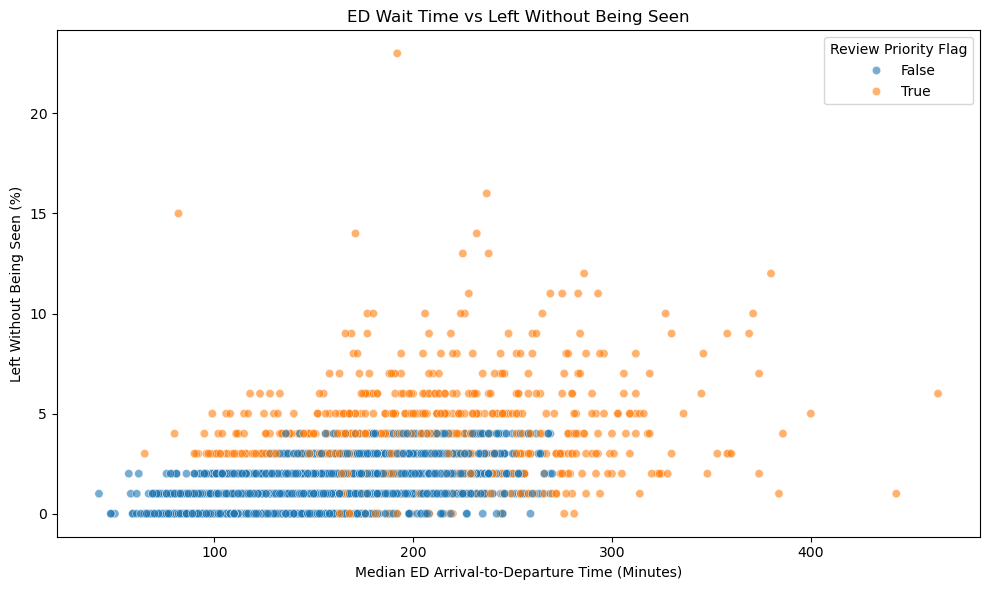

Saved: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\outputs\figures\op18b_vs_op22_review_priority.png


In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=analysis_df,
    x="op_18b_median_wait_min",
    y="op_22_lwbs_pct",
    hue="review_priority_flag",
    alpha=0.6
)

plt.title("ED Wait Time vs Left Without Being Seen")
plt.xlabel("Median ED Arrival-to-Departure Time (Minutes)")
plt.ylabel("Left Without Being Seen (%)")
plt.legend(title="Review Priority Flag")

plt.tight_layout()

visual3_path = figures_path / "op18b_vs_op22_review_priority.png"
plt.savefig(visual3_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", visual3_path)

### Visual 4 — Review-Priority Group Summary

This visual summarizes hospitals flagged for operational review by flag type.

The categories distinguish between hospitals with elevated ED wait time only, elevated left-without-being-seen percentage only, and hospitals elevated on both indicators.

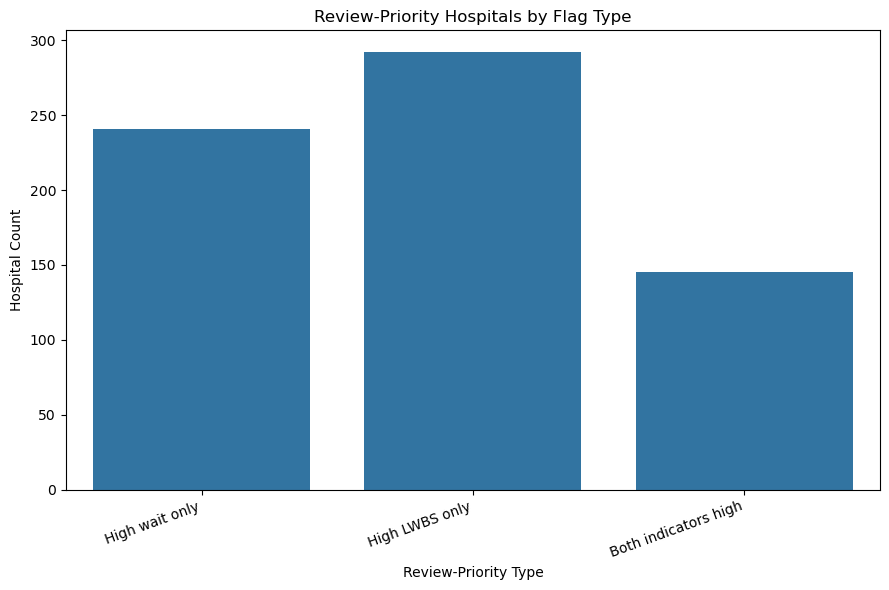

Saved: C:\Projects\AnalyticsPortfolio\healthcare-operations-cms\outputs\figures\review_priority_by_flag_type.png


In [30]:
plt.figure(figsize=(9, 6))

plot_df = flag_overlap_summary[
    flag_overlap_summary["metric"] != "any_review_priority"
].copy()

plot_df["metric"] = plot_df["metric"].replace({
    "high_wait_only": "High wait only",
    "high_lwbs_only": "High LWBS only",
    "both_high_wait_and_high_lwbs": "Both indicators high"
})

sns.barplot(
    data=plot_df,
    x="metric",
    y="count"
)

plt.title("Review-Priority Hospitals by Flag Type")
plt.xlabel("Review-Priority Type")
plt.ylabel("Hospital Count")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()

visual4_path = figures_path / "review_priority_by_flag_type.png"
plt.savefig(visual4_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", visual4_path)

In [31]:
plot_df["metric"] = pd.Categorical(
    plot_df["metric"],
    categories=[
        "Both indicators high",
        "High wait only",
        "High LWBS only"
    ],
    ordered=True
)

plot_df = plot_df.sort_values("metric")

## Block 7–8 Completion Checkpoint — Peer Benchmarking and Visuals

Blocks 7 and 8 are complete.

### Completed work

- Created the complete-case benchmark population using hospitals with:
  - EDV category
  - OP_18b median ED arrival-to-departure time
  - OP_22 left-without-being-seen percentage
- Confirmed benchmark population:
  - 3,777 hospitals
  - 3,777 unique facilities
- Calculated EDV-tier peer benchmarks:
  - OP_18b median
  - OP_18b 75th percentile
  - OP_18b 90th percentile
  - OP_22 median
  - OP_22 75th percentile
  - OP_22 90th percentile
- Assigned peer benchmark fields to each hospital.
- Calculated variance from EDV-tier peer medians.
- Validated that assigned peer medians matched actual EDV-tier medians.
- Created percentile-based review-priority flags.
- Created a review-priority candidate table.
- Exported benchmark outputs to `data/processed/`.
- Created four stakeholder-facing visuals.

### Benchmark population

The benchmark population includes hospitals with complete data for:

- `ed_volume_category`
- `op_18b_median_wait_min`
- `op_22_lwbs_pct`

Benchmark population:

- 3,777 hospitals
- 81.1% of the full analytical mart

### EDV-tier benchmark summary

EDV peer groups were large enough for descriptive benchmarking:

- low: 1,612 complete-case hospitals
- medium: 911 complete-case hospitals
- high: 551 complete-case hospitals
- very high: 703 complete-case hospitals

OP_18b median wait time generally increased across EDV categories:

- low: 120 minutes
- medium: 168 minutes
- high: 190 minutes
- very high: 194 minutes

OP_22 median values were lower overall but showed higher upper-tail values in higher EDV groups:

- low p90: 3%
- medium p90: 4%
- high p90: 5%
- very high p90: 5%

### Review-priority flag logic

A hospital was flagged as a review-priority candidate if it was at or above the EDV-tier 90th percentile for:

- OP_18b median ED arrival-to-departure time, or
- OP_22 left-without-being-seen percentage

This flag identifies candidates for operational review. It does not label hospitals as poor performers or diagnose causes.

### Review-priority results

Benchmark population:

- 3,777 hospitals

Flag results:

- High OP_18b wait only: 241 hospitals
- High OP_22 LWBS only: 292 hospitals
- Both indicators high: 145 hospitals
- Any review-priority flag: 678 hospitals

Overall, 678 hospitals, or 18.0% of the benchmark population, were flagged for potential operational review.

The review-priority percentage is higher than 10% because the flag uses an OR condition across two indicators, and OP_22 has tied whole-number values around